# 13 — Anomaly Detection & Highlighting
**When to use:** Automatically flag days where a metric behaves unusually — without having to visually scan every data point.

This is extremely practical for daily monitoring of paid spend, CVR, or activations.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])

daily = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()
daily['cvr'] = daily['activations'] / daily['sessions'] * 100

print(daily.shape)

(90, 4)


## 1. Z-score anomaly detection
A point is anomalous if it's more than N standard deviations from the mean.
This is the simplest and most practical approach for daily monitoring.

Mean CVR: 2.22%  Std: 0.05%
Anomalies detected: 6


/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_11764/178054611.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


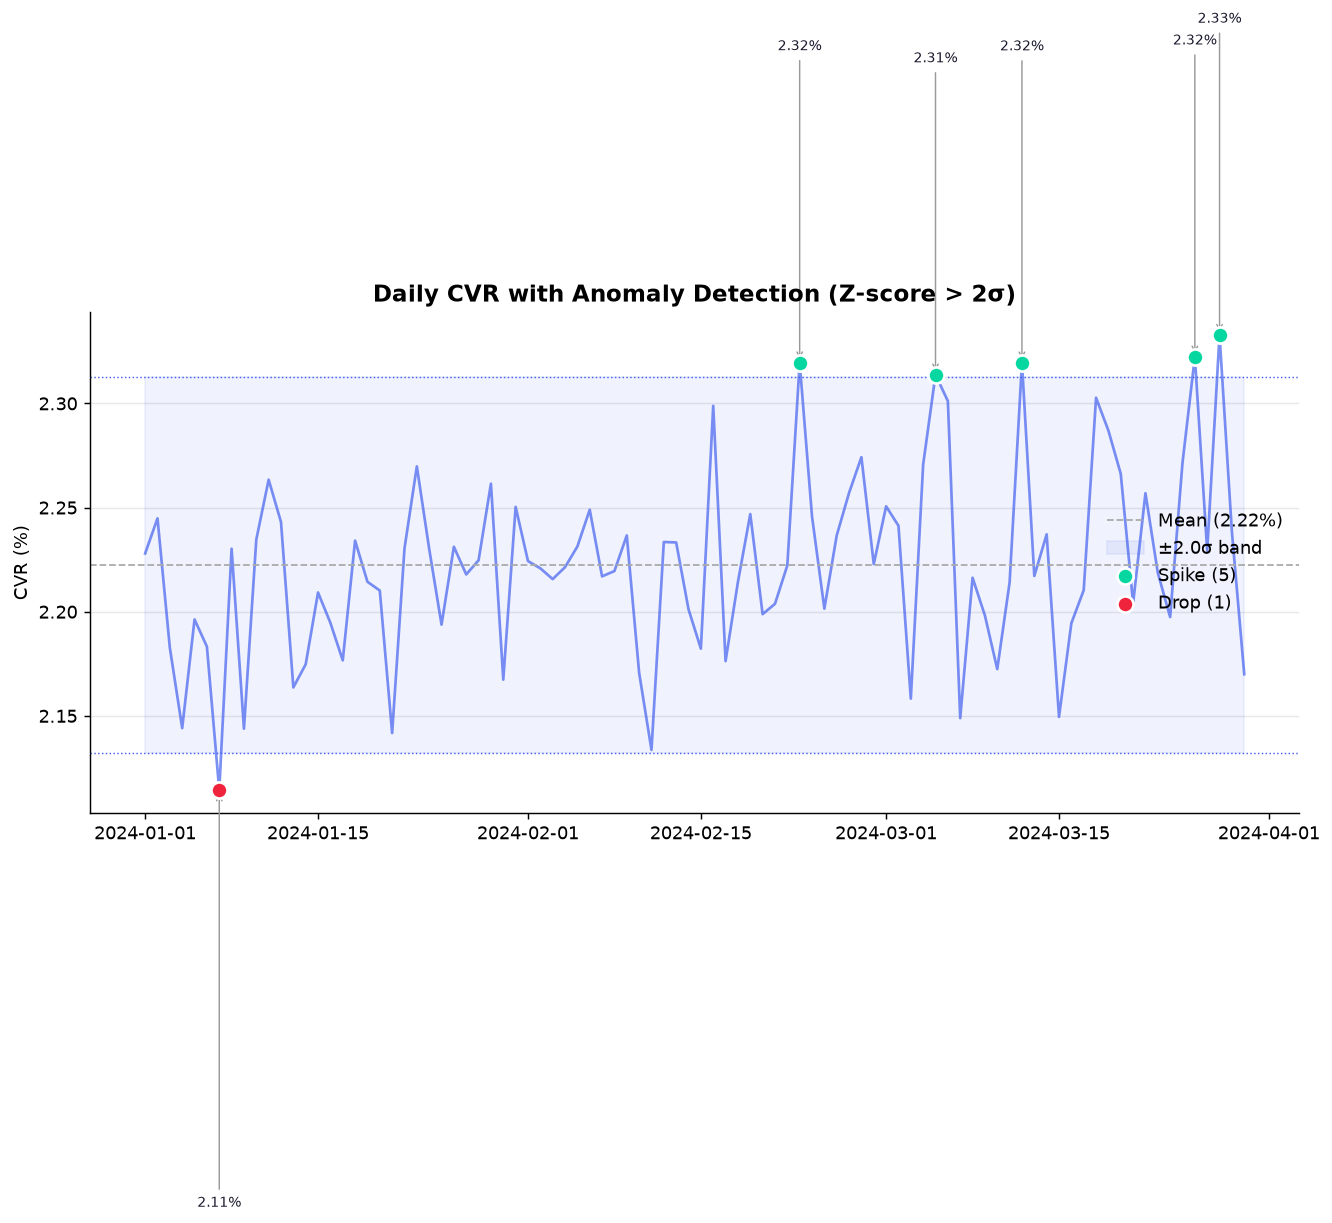

In [2]:
# Compute z-score: how many standard deviations from the mean
mean = daily['cvr'].mean()
std  = daily['cvr'].std()
daily['zscore'] = (daily['cvr'] - mean) / std

# Flag points beyond ±2 std devs as anomalies
THRESHOLD = 2.0
anomalies = daily[daily['zscore'].abs() > THRESHOLD]

print(f'Mean CVR: {mean:.2f}%  Std: {std:.2f}%')
print(f'Anomalies detected: {len(anomalies)}')

fig, ax = plt.subplots(figsize=(12, 5), dpi=130)

# Normal data
ax.plot(daily['date'], daily['cvr'], color='#4361ee', linewidth=1.5, alpha=0.7)

# Control band: mean ± 2 std
ax.axhline(mean, color='#aaa', linewidth=1, linestyle='--', label=f'Mean ({mean:.2f}%)')
ax.fill_between(daily['date'],
                mean - THRESHOLD * std,
                mean + THRESHOLD * std,
                alpha=0.08, color='#4361ee', label=f'±{THRESHOLD}σ band')
ax.axhline(mean + THRESHOLD * std, color='#4361ee', linewidth=0.8, linestyle=':')
ax.axhline(mean - THRESHOLD * std, color='#4361ee', linewidth=0.8, linestyle=':')

# Highlight anomalies
above = anomalies[anomalies['zscore'] > 0]
below = anomalies[anomalies['zscore'] < 0]

ax.scatter(above['date'], above['cvr'],
           color='#06d6a0', s=80, zorder=5, edgecolors='white', linewidth=1.5,
           label=f'Spike ({len(above)})')
ax.scatter(below['date'], below['cvr'],
           color='#ef233c', s=80, zorder=5, edgecolors='white', linewidth=1.5,
           label=f'Drop ({len(below)})')

# Annotate each anomaly
for _, row in anomalies.iterrows():
    offset = 0.15 if row['zscore'] > 0 else -0.2
    ax.annotate(f"{row['cvr']:.2f}%",
                xy=(row['date'], row['cvr']),
                xytext=(row['date'], row['cvr'] + offset),
                ha='center', fontsize=7.5, color='#1a1a2e',
                arrowprops=dict(arrowstyle='->', lw=0.8, color='#999'))

ax.set_title('Daily CVR with Anomaly Detection (Z-score > 2σ)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('CVR (%)')
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('data/13_anomaly_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Rolling window anomaly detection
Better for trending data: compare each day to the rolling mean of the past N days, not the global mean.
This catches anomalies even when the overall trend is increasing.

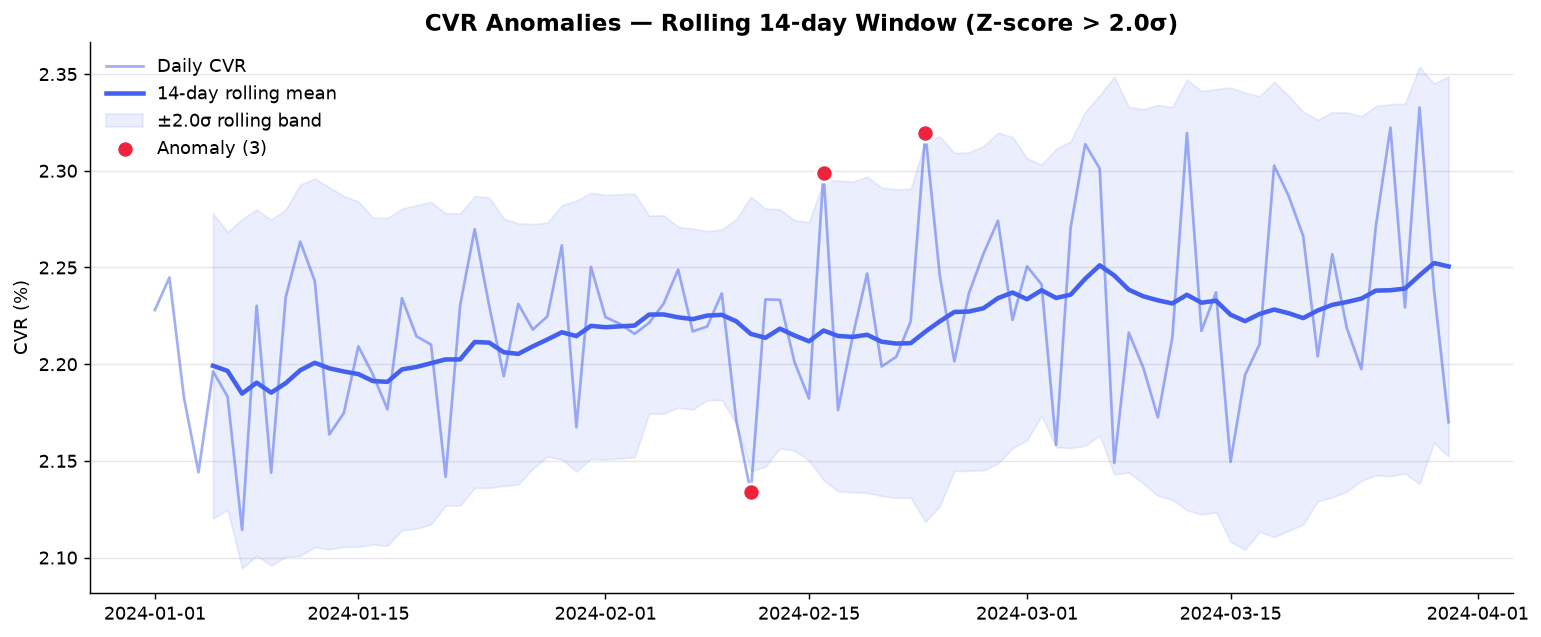

In [3]:
WINDOW = 14  # compare each day to the past 14 days

daily['roll_mean'] = daily['cvr'].rolling(WINDOW, min_periods=5).mean()
daily['roll_std']  = daily['cvr'].rolling(WINDOW, min_periods=5).std()
daily['roll_z']    = (daily['cvr'] - daily['roll_mean']) / daily['roll_std']

anomalies_roll = daily[daily['roll_z'].abs() > THRESHOLD].dropna()

fig, ax = plt.subplots(figsize=(12, 5), dpi=130)

ax.plot(daily['date'], daily['cvr'],
        color='#4361ee', linewidth=1.5, alpha=0.5, label='Daily CVR')
ax.plot(daily['date'], daily['roll_mean'],
        color='#4361ee', linewidth=2.5, label=f'{WINDOW}-day rolling mean')
ax.fill_between(daily['date'],
                daily['roll_mean'] - THRESHOLD * daily['roll_std'],
                daily['roll_mean'] + THRESHOLD * daily['roll_std'],
                alpha=0.1, color='#4361ee', label=f'±{THRESHOLD}σ rolling band')

# Anomalies
ax.scatter(anomalies_roll['date'], anomalies_roll['cvr'],
           color='#ef233c', s=90, zorder=5,
           edgecolors='white', linewidth=1.5,
           label=f'Anomaly ({len(anomalies_roll)})')

ax.set_title(f'CVR Anomalies — Rolling {WINDOW}-day Window (Z-score > {THRESHOLD}σ)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('CVR (%)')
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 3. Multi-metric anomaly dashboard

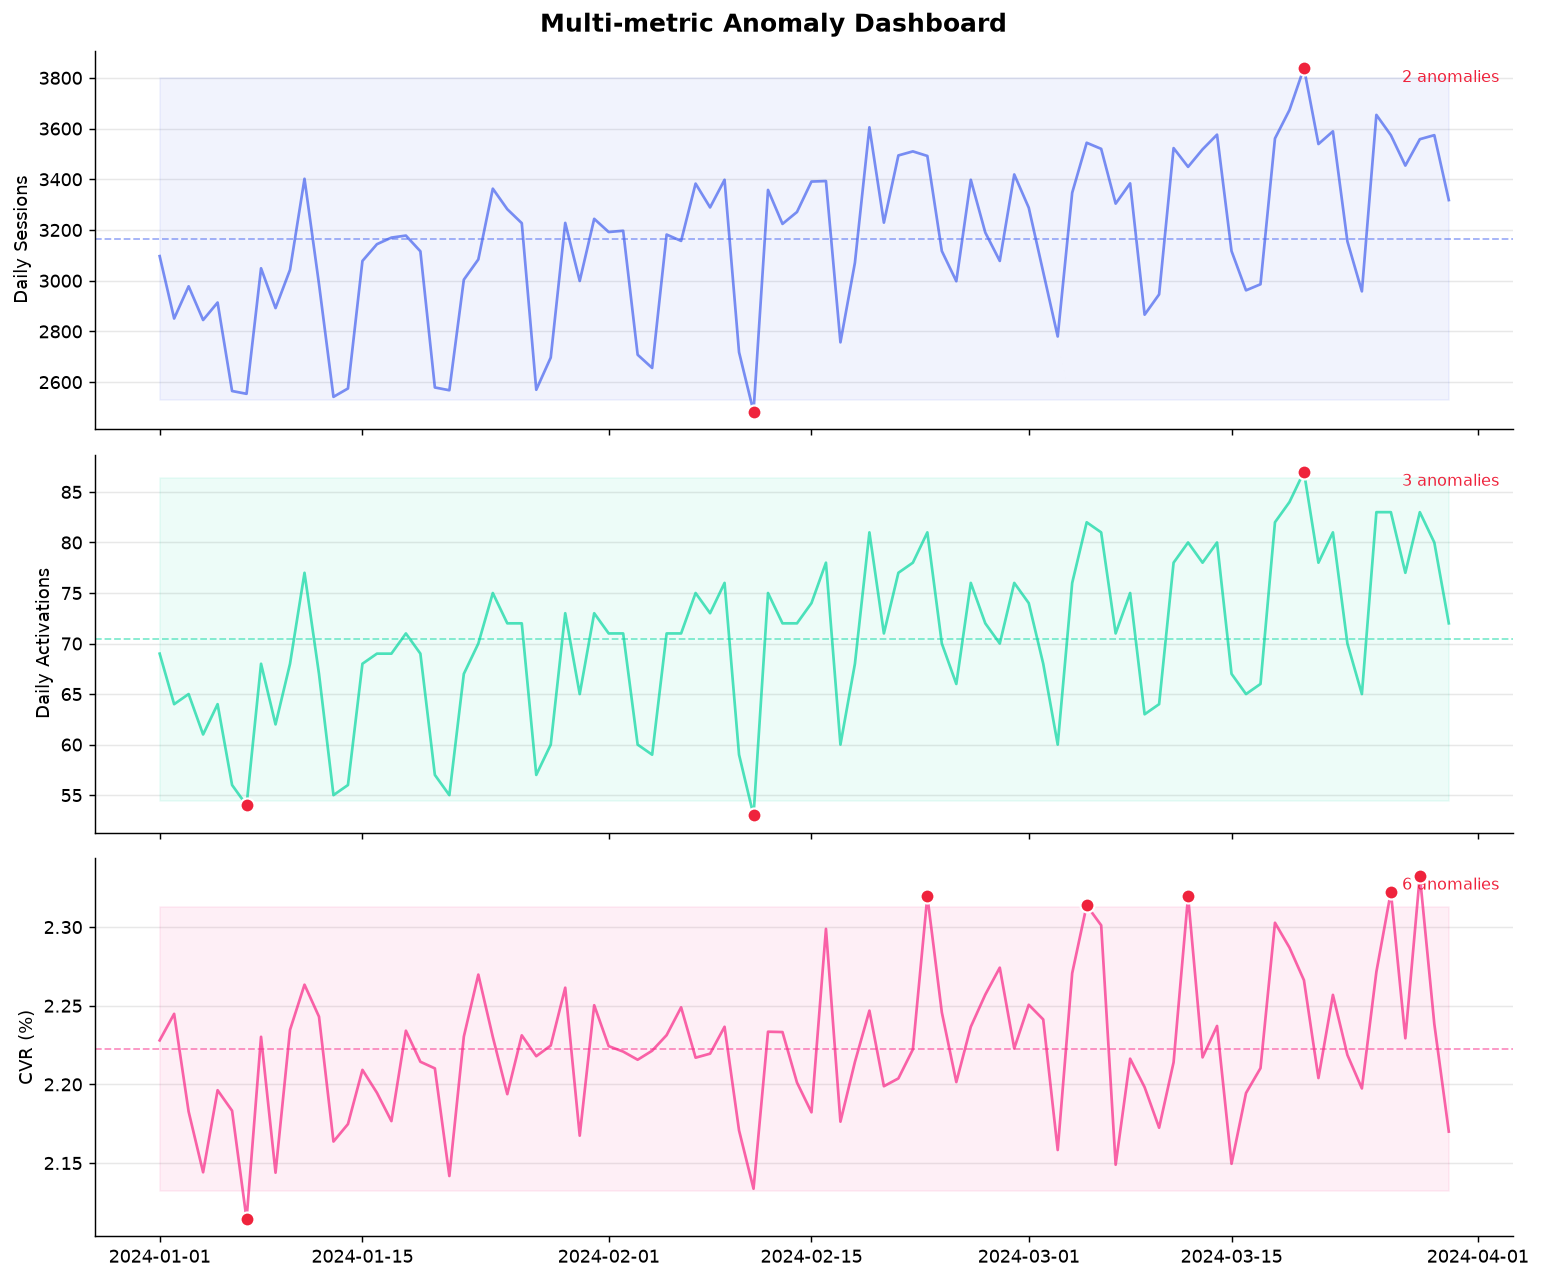

In [4]:
metrics = [
    ('sessions',    'Daily Sessions',    '#4361ee'),
    ('activations', 'Daily Activations', '#06d6a0'),
    ('cvr',         'CVR (%)',           '#f72585'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), dpi=130, sharex=True)

for ax, (metric, label, color) in zip(axes, metrics):
    values = daily[metric]
    m, s   = values.mean(), values.std()
    z      = (values - m) / s
    anom   = daily[z.abs() > 2]

    ax.plot(daily['date'], values, color=color, linewidth=1.5, alpha=0.7)
    ax.fill_between(daily['date'], m - 2*s, m + 2*s,
                    alpha=0.07, color=color)
    ax.axhline(m, color=color, linewidth=1, linestyle='--', alpha=0.5)
    ax.scatter(anom['date'], anom[metric],
               color='#ef233c', s=60, zorder=5,
               edgecolors='white', linewidth=1.2)

    ax.set_ylabel(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
    ax.set_axisbelow(True)

    # Count in corner
    ax.text(0.99, 0.95, f'{len(anom)} anomalies',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='#ef233c')

fig.suptitle('Multi-metric Anomaly Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/13_anomaly_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary
| Method | Formula | Best for |
|---|---|---|
| **Global Z-score** | `(x - mean) / std` | Stable metrics without trend |
| **Rolling Z-score** | `(x - roll_mean) / roll_std` | Trending metrics |
| **IQR method** | Flag outside `[Q1-1.5*IQR, Q3+1.5*IQR]` | Skewed distributions |

**Practical tip:** For daily monitoring, rolling Z-score with a 14-day window catches real anomalies while ignoring seasonal trends.